In [1]:

# Import packages
import pandas as pd
import numpy as np
import matplotlib
from matplotlib import dates as mdates
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from pmdarima import auto_arima
import pmdarima as pm
from scipy.stats import boxcox
from scipy.special import inv_boxcox

from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error, mean_squared_error
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from busy_airports.baselines import NaiveSeasonalWithDrift, TripleExponentialSmoothing
from busy_airports.preprocessing import load_data, retrieve_airport_data
from busy_airports.metrics import evaluate_forecast
from busy_airports.data_splits import make_rolling_splits, make_rolling_splits_weekly
from busy_airports.models import STLArima



In [2]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
#Import and process daily and weekly data for Chicago airport
data = load_data("../data/tsa-throughput-data-complete.csv")
data_ord_d = retrieve_airport_data(data, "ORD", frequency="D") #Daily data
data_ord_w = retrieve_airport_data(data, "ORD", frequency="W") #Weekly data


In [4]:
#Let's visualize the daily and weekly throughput data for Chicago O'Hare
px.line(data_ord_d, x='datetime', y='total_passenger_throughput', 
        labels={'total_passenger_throughput': 'Daily Throughput'},
        template="simple_white", 
        title='Daily Throughput at ORD',
        height=500, width=1000).update_layout(font=dict(size=14), title_x=0.5).show()

px.line(data_ord_w, x='datetime', y='total_passenger_throughput', 
        labels={'total_passenger_throughput': 'Weekly Throughput'},
        template="simple_white", 
        title='Weekly Throughput at ORD',
        height=500, width=1000).update_layout(font=dict(size=14), title_x=0.5).show()

We want to run STL and ARIMA on this data. We keep the data after June 2025 untouched for testing. We will define the training data first. We will eventually run STL and ARIMA on cross validated splits. We first use the entire training data to find the best parameters for Arima.

Daily Data Analysis

In [5]:
data_ord_d_train= data_ord_d[data_ord_d["datetime"] < "2025-06-24"]  #Daily training data

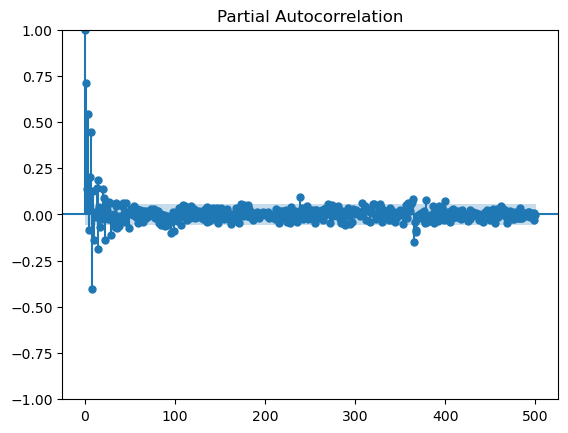

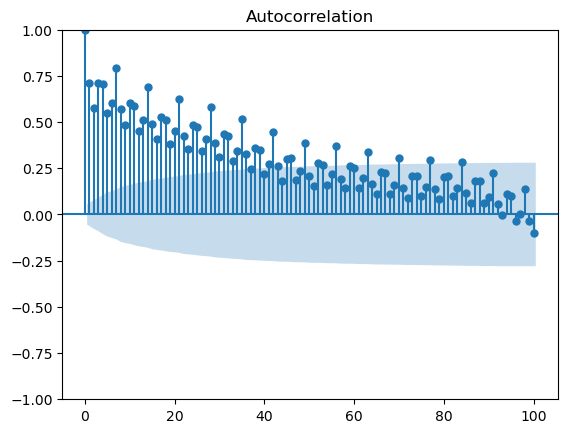

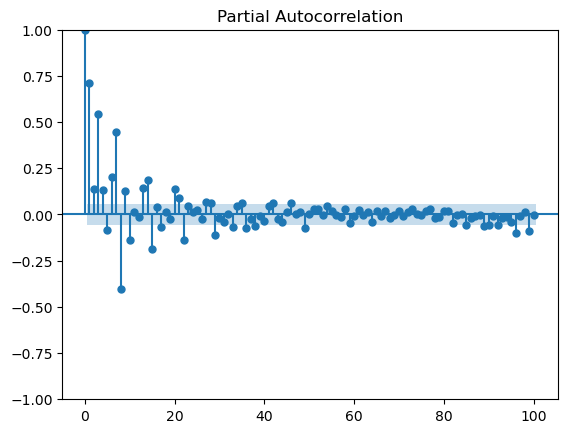

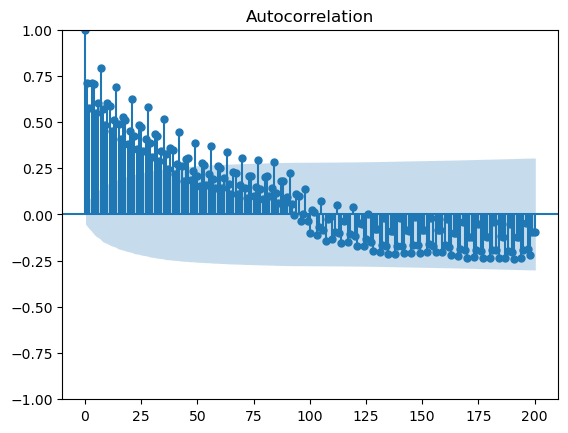

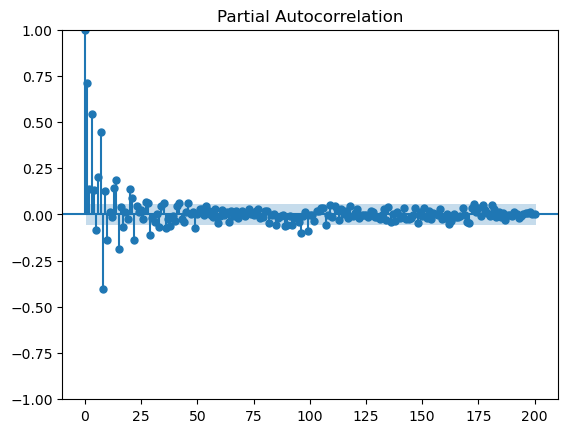

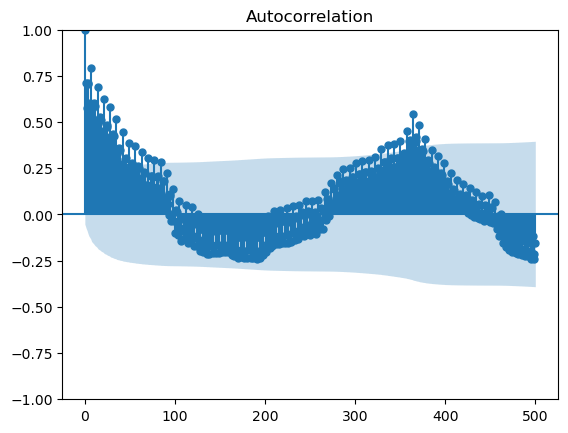

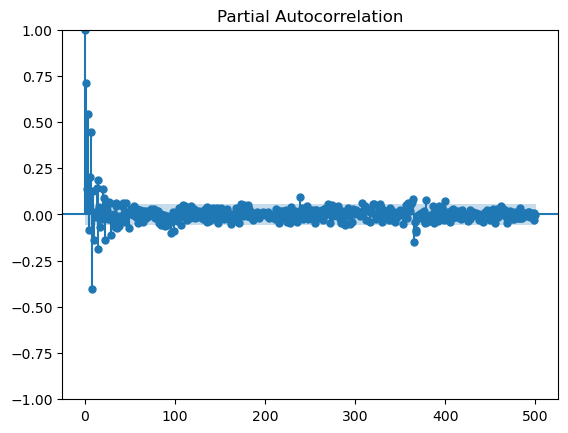

In [23]:
#ACF, PACF plots

plot_acf(data_ord_d_train['total_passenger_throughput'], lags=100)
plot_pacf(data_ord_d_train['total_passenger_throughput'], lags=100)


plot_acf(data_ord_d_train['total_passenger_throughput'], lags=200)
plot_pacf(data_ord_d_train['total_passenger_throughput'], lags=200)


plot_acf(data_ord_d_train['total_passenger_throughput'], lags=500)
plot_pacf(data_ord_d_train['total_passenger_throughput'], lags=500)

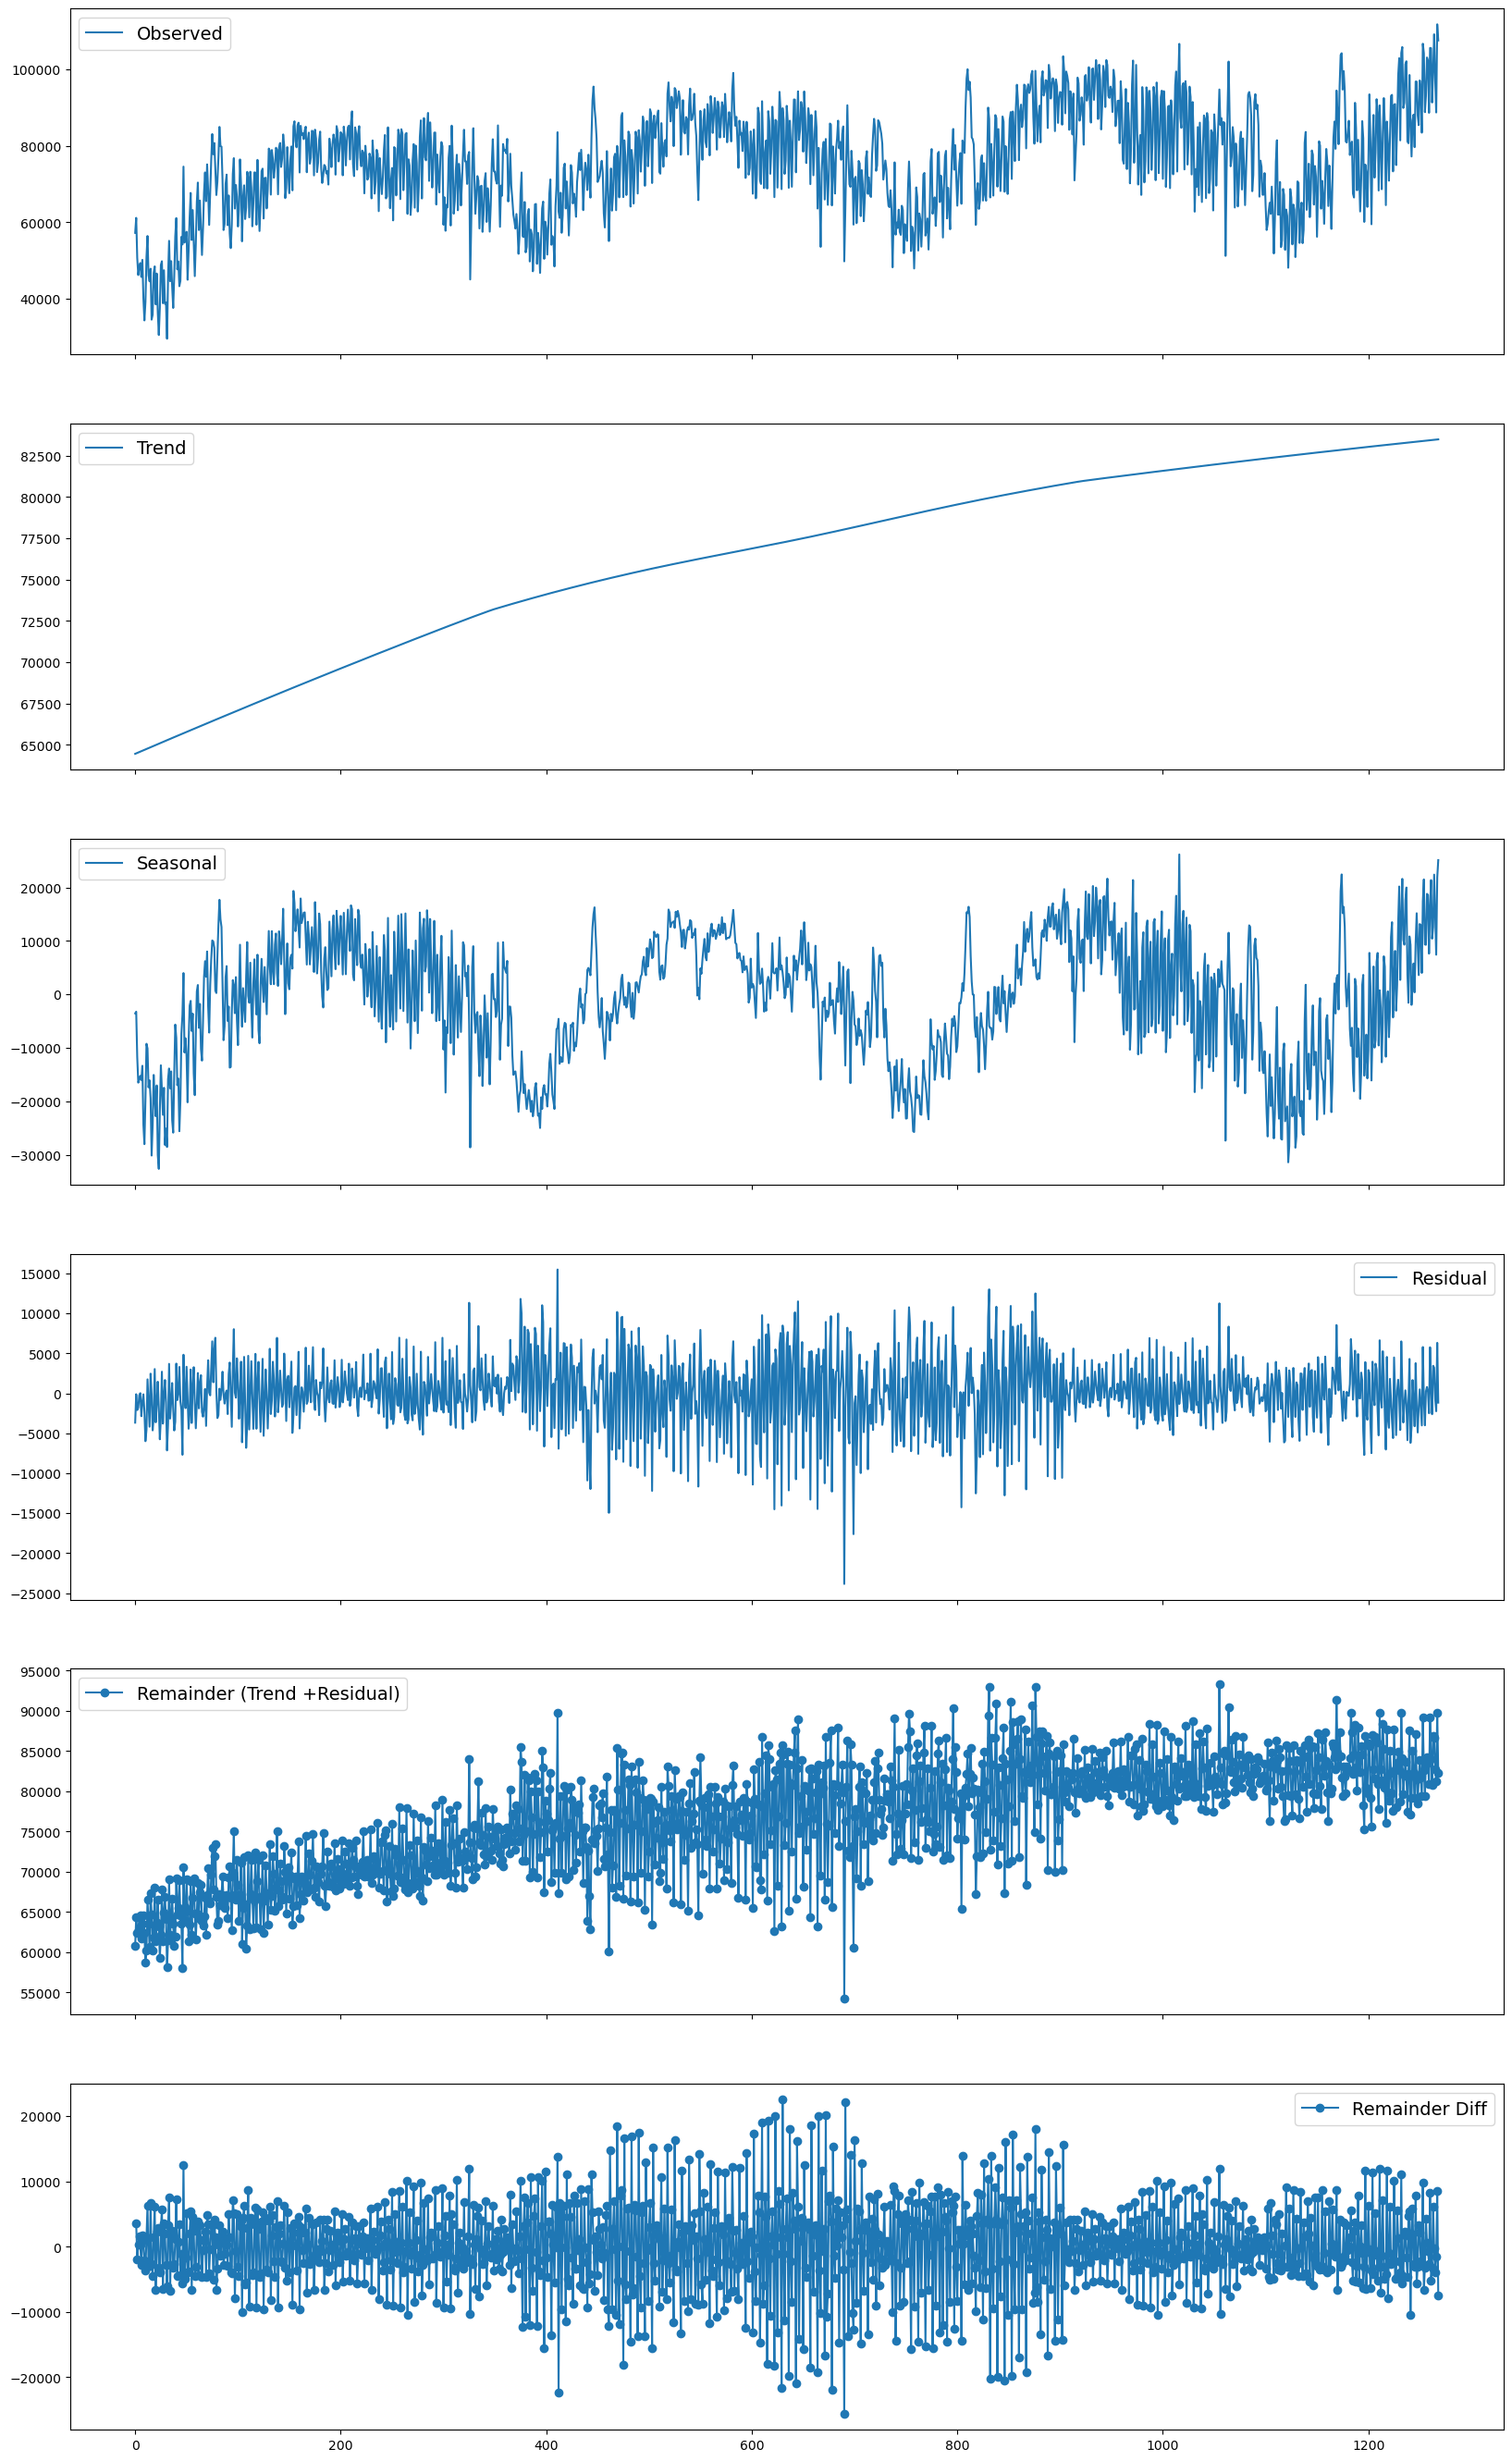

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=24236.869, Time=10.41 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=25891.482, Time=0.14 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=24824.667, Time=3.88 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=24671.008, Time=3.93 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=25889.491, Time=0.09 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=24580.467, Time=9.04 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=24458.044, Time=2.73 sec
 ARIMA(2,1,2)(2,0,1)[7] intercept   : AIC=24234.571, Time=14.54 sec
 ARIMA(2,1,2)(2,0,0)[7] intercept   : AIC=24300.849, Time=13.95 sec
 ARIMA(2,1,2)(2,0,2)[7] intercept   : AIC=inf, Time=13.04 sec
 ARIMA(2,1,2)(1,0,2)[7] intercept   : AIC=24235.324, Time=10.65 sec
 ARIMA(1,1,2)(2,0,1)[7] intercept   : AIC=24551.155, Time=10.18 sec
 ARIMA(2,1,1)(2,0,1)[7] intercept   : AIC=24219.731, Time=15.69 sec
 ARIMA(2,1,1)(1,0,1)[7] intercept   : AIC=24223.464, Time=5.25 sec
 ARIMA(2,1,1)(2,0,

,order,"(5, ...)"
,seasonal_order,"(2, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,50
,suppress_warnings,True
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,{}
,trend,None
,with_intercept,False


In [24]:
# Obtain the auto arima model fitted to the training set (effectively does cross validation to select optimal hyperparameters)
stl_daily = STL(data_ord_d_train['total_passenger_throughput'], period=365)
stl_daily_results = stl_daily.fit()

stl_daily_trend = stl_daily_results.trend
stl_daily_seasonal = stl_daily_results.seasonal
stl_daily_resid = stl_daily_results.resid
stl_daily_base = stl_daily_results.observed

stl_daily_trend_diff = stl_daily_trend.diff()
stl_daily_remainder = stl_daily_trend + stl_daily_resid
stl_daily_remainder_diff = stl_daily_remainder.diff()

fig, ax = plt.subplots(6, 1, figsize=(20, 34), sharex=True)
ax[0].plot(stl_daily_base, label='Observed')
ax[0].legend(fontsize=14)
ax[1].plot(stl_daily_trend, label='Trend')
ax[1].legend(fontsize=14)
ax[2].plot(stl_daily_seasonal, label='Seasonal')
ax[2].legend(fontsize=14)
ax[3].plot(stl_daily_resid, label='Residual')
ax[3].legend(fontsize=14)
ax[4].plot(stl_daily_remainder, label='Remainder (Trend +Residual)', marker='o')
ax[4].legend(fontsize=14)
ax[5].plot(stl_daily_remainder_diff, label='Remainder Diff', marker='o')
ax[5].legend(fontsize=14)
plt.show()


auto_arima(stl_daily_remainder, seasonal=True,trace = True, m=7, stepwise=True, suppress_warnings=True, error_action='ignore')


Let's use cross-validated splits now for better modelling. We use a baseline of the data from 2022 and 2023, and an additional 90 days for each split, for a total of five splits.

In [6]:
#creating splits
splits_d = make_rolling_splits(data_ord_d_train, date_col='datetime', n_splits=5, step_days=90)

Split 1: train → 2024-03-30 | test 2024-03-31 → 2024-06-28 (90 days)
Split 2: train → 2024-06-28 | test 2024-06-29 → 2024-09-26 (90 days)
Split 3: train → 2024-09-26 | test 2024-09-27 → 2024-12-25 (90 days)
Split 4: train → 2024-12-25 | test 2024-12-26 → 2025-03-25 (90 days)
Split 5: train → 2025-03-25 | test 2025-03-26 → 2025-06-23 (90 days)


In [8]:
#Arima orders for the remainder component of the STL decomposition
p = 5
d = 1
q = 2
P = 2
D = 0
Q = 1
s = 7
results_stl_d=[]
#Running STL + ARIMA on daily data using the splits created above.
for i, (train_idx, test_idx) in enumerate(splits_d):
        if len(test_idx) == 0:
            print(f"Split {i+1}: empty test set, skipping")
            continue

        train = data_ord_d_train.loc[train_idx].copy()
        test  = data_ord_d_train.loc[test_idx].copy()
        n_forecast = len(test_idx)
        model = STLArima(season_length=365,arima_order=(p,d,q), seasonal_order=(P,D,Q,s))
        model.fit(train['total_passenger_throughput'])
        forecasts, lower_bound, upper_bound = model.forecast(n_forecast)
        actuals  = test['total_passenger_throughput'].values
        metrics = evaluate_forecast(actuals, forecasts, model_name=f"Split {i+1}")
        metrics['split'] = i + 1
        results_stl_d.append(metrics)
        print(f"Split {i+1} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")

results_stl_d_df = pd.DataFrame(results_stl_d).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_stl_d_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_stl_d_df['mape'].mean()*100:.2f}%")
print(f"  RMSE: {results_stl_d_df['rmse'].mean():,.0f}")  



Split 1 - MAE: 8691, MAPE: 10.46%, RMSE: 10341
Split 2 - MAE: 9185, MAPE: 10.66%, RMSE: 11412
Split 3 - MAE: 10365, MAPE: 13.34%, RMSE: 13362
Split 4 - MAE: 7948, MAPE: 11.84%, RMSE: 9891
Split 5 - MAE: 9762, MAPE: 11.96%, RMSE: 12145

CV Average:
  MAE:  9,190
  MAPE: 11.65%
  RMSE: 11,430


Here's a plot of the predicted values across splits along with a 95% confidence interval

In [10]:
data_ord_d_train = data_ord_d_train.set_index('datetime')
data_ord_d_train.index = pd.to_datetime(data_ord_d_train.index)

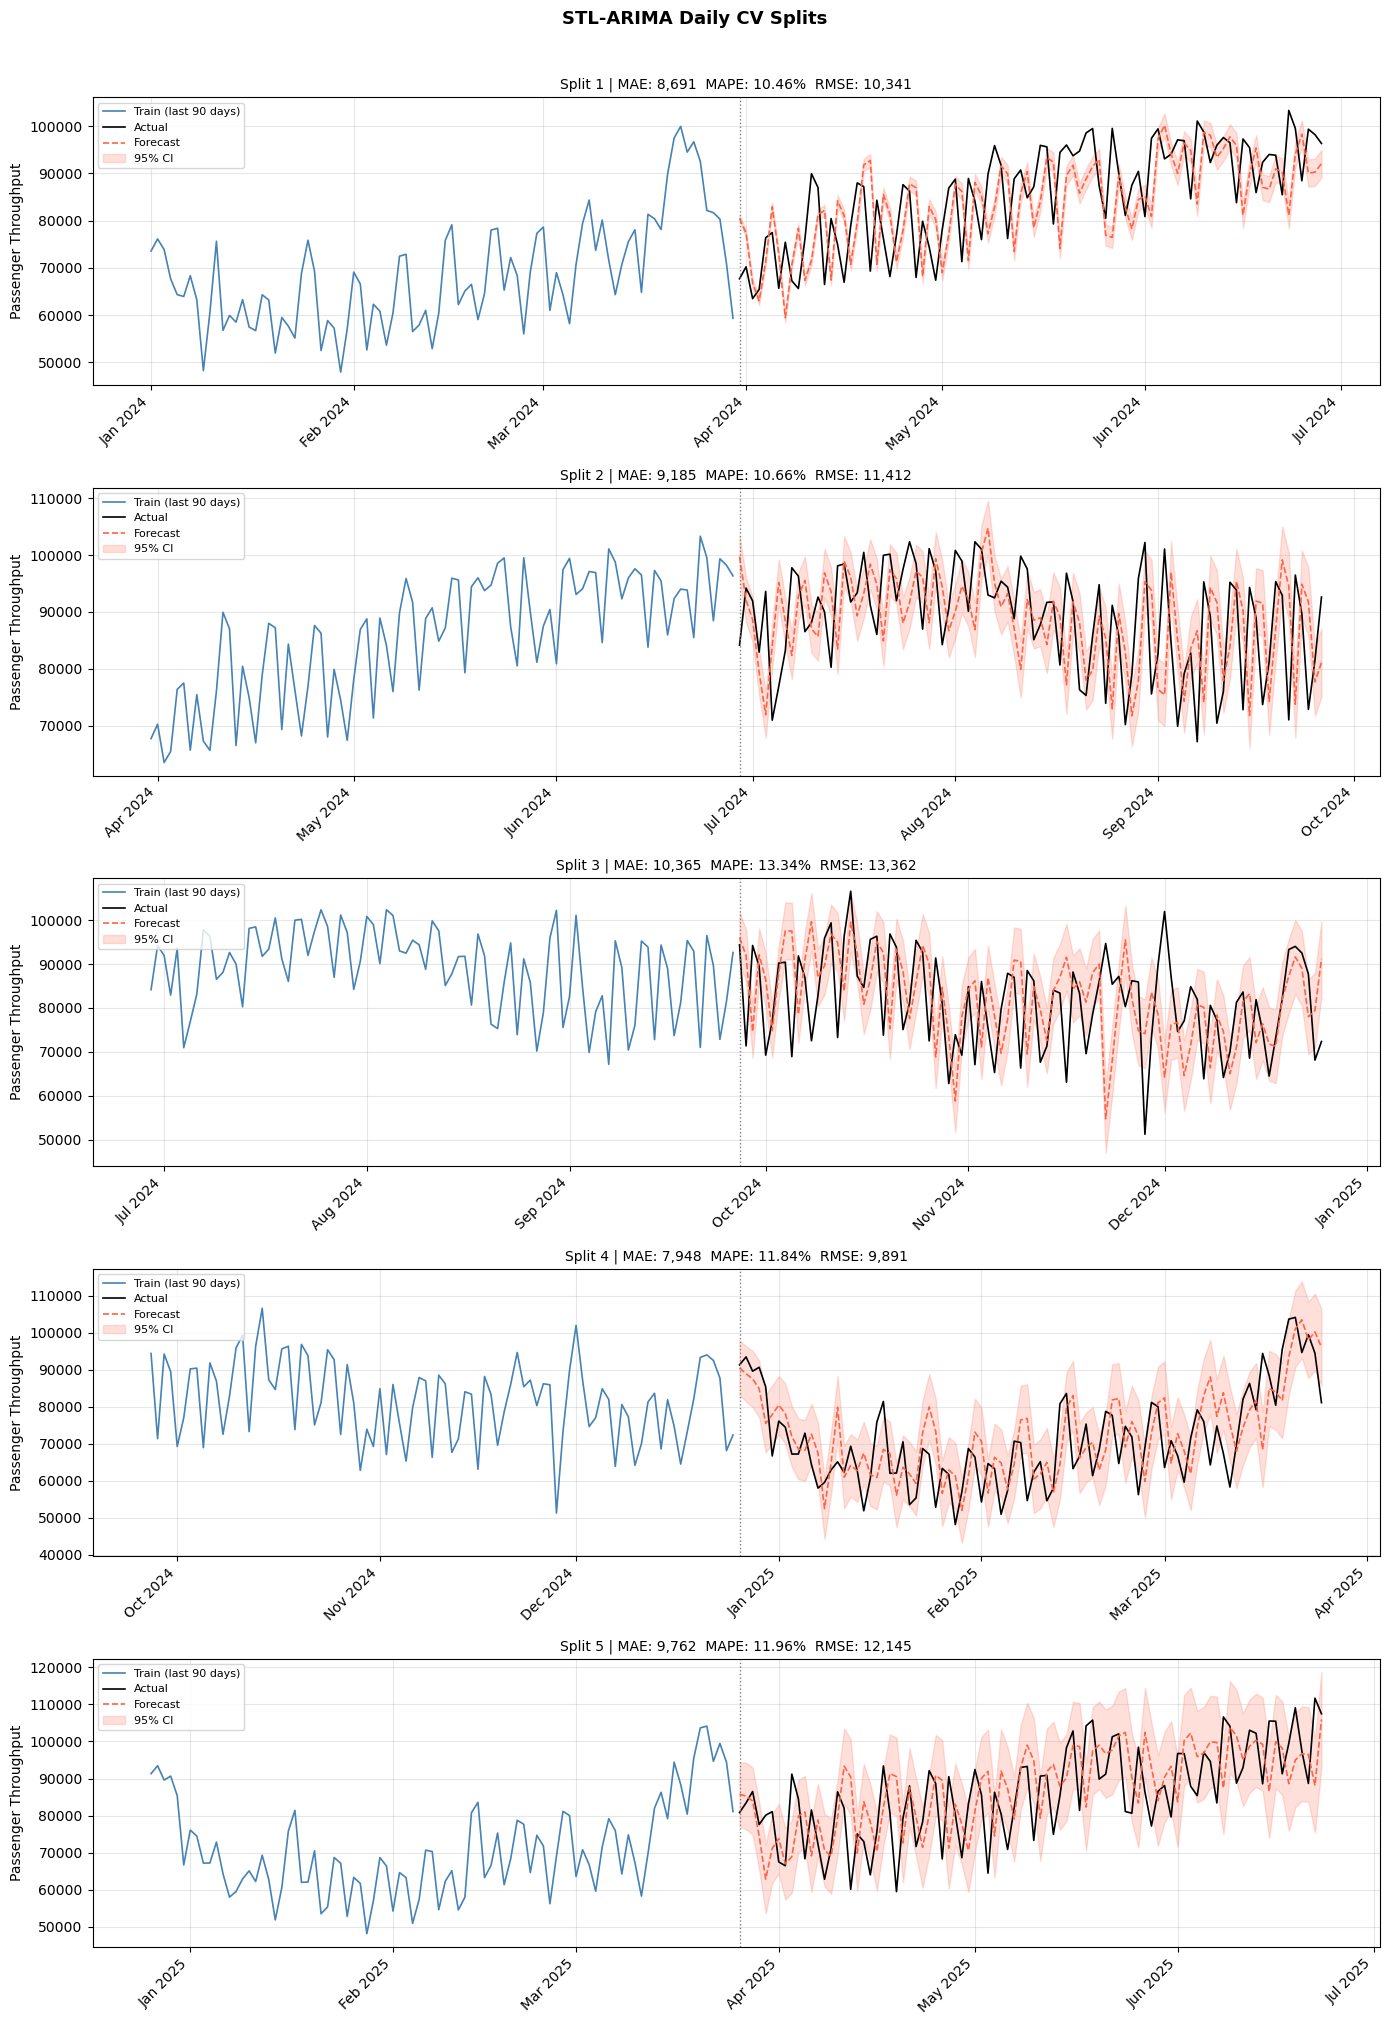

In [11]:

                                        
import matplotlib.dates as mdates

fig, axes = plt.subplots(len(splits_d), 1, figsize=(14, 4 * len(splits_d)))
axes = axes if hasattr(axes, '__len__') else [axes]  # handle single split edge case

for i, (train_idx, test_idx) in enumerate(splits_d):
    ax = axes[i]

    if len(test_idx) == 0:
        print(f"Split {i+1}: empty test set, skipping")
        ax.set_visible(False)
        continue

    train = data_ord_d_train.iloc[train_idx].copy()
    test  = data_ord_d_train.iloc[test_idx].copy()
    n_forecast = len(test_idx)

    model = STLArima(season_length=365, arima_order=(p,d,q), seasonal_order=(P,D,Q,s))
    model.fit(train['total_passenger_throughput'])
    forecasts, lower_bound, upper_bound = model.forecast(n_forecast)

    actuals = test['total_passenger_throughput'].values
    metrics = evaluate_forecast(actuals, forecasts, model_name=f"Split {i+1}")
    metrics['split'] = i + 1
    results_stl_d.append(metrics)

    # --- Plotting ---
    train_dates = train.index
    test_dates  = test.index

    # Plot last N days of training data for context
    context_window = min(90, len(train))
    ax.plot(train_dates[-context_window:],
            train['total_passenger_throughput'].values[-context_window:],
            color='steelblue', label='Train (last 90 days)', linewidth=1.2)

    # Actuals in test window
    ax.plot(test_dates, actuals,
            color='black', label='Actual', linewidth=1.2)

    # Forecast
    ax.plot(test_dates, forecasts,
            color='tomato', label='Forecast', linewidth=1.2, linestyle='--')

    # 95% Confidence interval
    ax.fill_between(test_dates, lower_bound, upper_bound,
                    color='tomato', alpha=0.2, label='95% CI')

    # Vertical line separating train/test
    ax.axvline(x=test_dates[0], color='gray', linestyle=':', linewidth=1)

    ax.set_title(
        f"Split {i+1} | MAE: {metrics['mae']:,.0f}  "
        f"MAPE: {100*metrics['mape']:.2f}%  "
        f"RMSE: {metrics['rmse']:,.0f}",
        fontsize=10
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_ylabel('Passenger Throughput')
    ax.grid(True, alpha=0.3)

plt.suptitle('STL-ARIMA Daily CV Splits', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('stl_arima_cv_splits.png', dpi=150, bbox_inches='tight')
plt.show()


Weekly Data Analysis

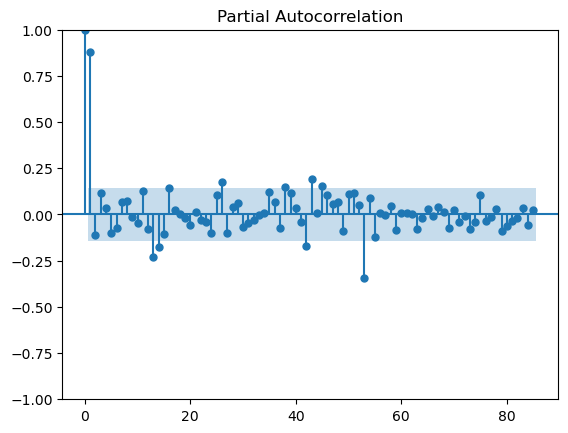

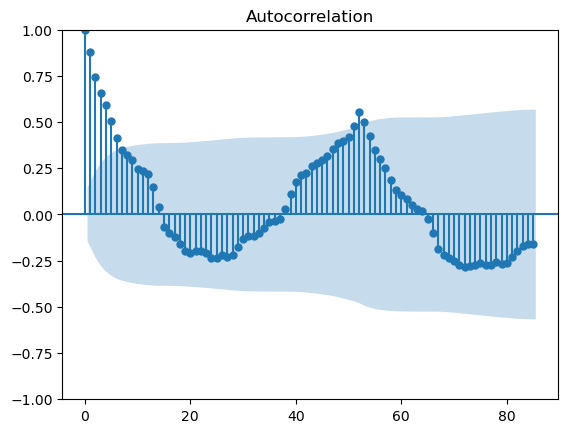

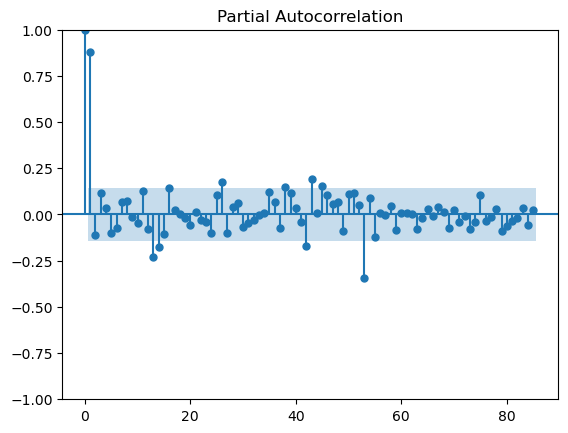

In [12]:

data_ord_w_train= data_ord_w[data_ord_w.index <= 181] #Weekly training data
#ACF, PACF plots

plot_acf(data_ord_w_train['total_passenger_throughput'], lags=85)
plot_pacf(data_ord_w_train['total_passenger_throughput'], lags=85)

In [ ]:
stl_weekly = STL(data_ord_w_train['total_passenger_throughput'], period=52)
stl_weekly_results = stl_weekly.fit()

stl_weekly_trend = stl_weekly_results.trend
stl_weekly_seasonal = stl_weekly_results.seasonal
stl_weekly_resid = stl_weekly_results.resid
stl_weekly_base = stl_weekly_results.observed

stl_weekly_trend_diff = stl_weekly_trend.diff()
stl_weekly_remainder = stl_weekly_trend + stl_weekly_resid
stl_weekly_remainder_diff = stl_weekly_remainder.diff()



fig, ax = plt.subplots(6, 1, figsize=(20, 34), sharex=True)

ax[0].plot(stl_weekly_base, label='Observed')
ax[0].legend(fontsize=14)
ax[1].plot(stl_weekly_trend, label='Trend')
ax[1].legend(fontsize=14)
ax[2].plot(stl_weekly_seasonal, label='Seasonal')
ax[2].legend(fontsize=14)
ax[3].plot(stl_weekly_resid, label='Residual')
ax[3].legend(fontsize=14)
ax[4].plot(stl_weekly_remainder, label='Remainder (Trend + Residual)', marker='o')
ax[4].legend(fontsize=14)
ax[5].plot(stl_weekly_remainder_diff, label='Remainder Diff', marker='o')
ax[5].legend(fontsize=14)

plt.show()

auto_arima(stl_weekly_remainder, seasonal=True,trace = True, stepwise=True, suppress_warnings=True, error_action='ignore')


Split 1: train → row 116 (2024-03-31) | test rows 117–129 (2024-04-07 → 2024-06-30) (13 weeks)
Split 2: train → row 129 (2024-06-30) | test rows 130–142 (2024-07-07 → 2024-09-29) (13 weeks)
Split 3: train → row 142 (2024-09-29) | test rows 143–155 (2024-10-06 → 2024-12-29) (13 weeks)
Split 4: train → row 155 (2024-12-29) | test rows 156–168 (2025-01-05 → 2025-03-30) (13 weeks)
Split 5: train → row 168 (2025-03-30) | test rows 169–181 (2025-04-06 → 2025-06-29) (13 weeks)


In [13]:
#Creating Weekly Splits
splits_w = make_rolling_splits_weekly(data_ord_w_train, date_col='datetime', n_splits=5, step_weeks=13)

Split 1: train → row 116 (2024-03-31) | test rows 117–129 (2024-04-07 → 2024-06-30) (13 weeks)
Split 2: train → row 129 (2024-06-30) | test rows 130–142 (2024-07-07 → 2024-09-29) (13 weeks)
Split 3: train → row 142 (2024-09-29) | test rows 143–155 (2024-10-06 → 2024-12-29) (13 weeks)
Split 4: train → row 155 (2024-12-29) | test rows 156–168 (2025-01-05 → 2025-03-30) (13 weeks)
Split 5: train → row 168 (2025-03-30) | test rows 169–181 (2025-04-06 → 2025-06-29) (13 weeks)


In [16]:
#Running STL + ARIMA on weekly data using the splits created above.

results_stl_w = []
for i, (train_idx, test_idx) in enumerate(splits_w):
        if len(test_idx) == 0:
            print(f"Split {i+1}: empty test set, skipping")
            continue

        train = data_ord_w_train.loc[train_idx].copy()
        test  = data_ord_w_train.loc[test_idx].copy()
        n_forecast = len(test_idx)
        model = STLArima(season_length=52,arima_order=(0,1,0), seasonal_order=(0,0,0,0))
        model.fit(train['total_passenger_throughput'])
        forecasts, lower_bound, upper_bound = model.forecast(n_forecast)
        actuals  = test['total_passenger_throughput'].values
        metrics = evaluate_forecast(actuals, forecasts, model_name=f"Split {i+1}")
        metrics['split'] = i + 1
        results_stl_w.append(metrics)
        print(f"Split {i+1} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")

results_stl_w_df = pd.DataFrame(results_stl_w).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_stl_w_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_stl_w_df['mape'].mean()*100:.2f}%")
print(f"  RMSE: {results_stl_w_df['rmse'].mean():,.0f}")  



Split 1 - MAE: 15545, MAPE: 2.56%, RMSE: 19029
Split 2 - MAE: 13794, MAPE: 2.19%, RMSE: 15848
Split 3 - MAE: 22343, MAPE: 3.89%, RMSE: 26690
Split 4 - MAE: 22879, MAPE: 4.91%, RMSE: 27775
Split 5 - MAE: 30219, MAPE: 5.17%, RMSE: 36578

CV Average:
  MAE:  20,956
  MAPE: 3.74%
  RMSE: 25,184


In [14]:

data_ord_w_train = data_ord_w_train.set_index('datetime')
data_ord_w_train.index = pd.to_datetime(data_ord_w_train.index)


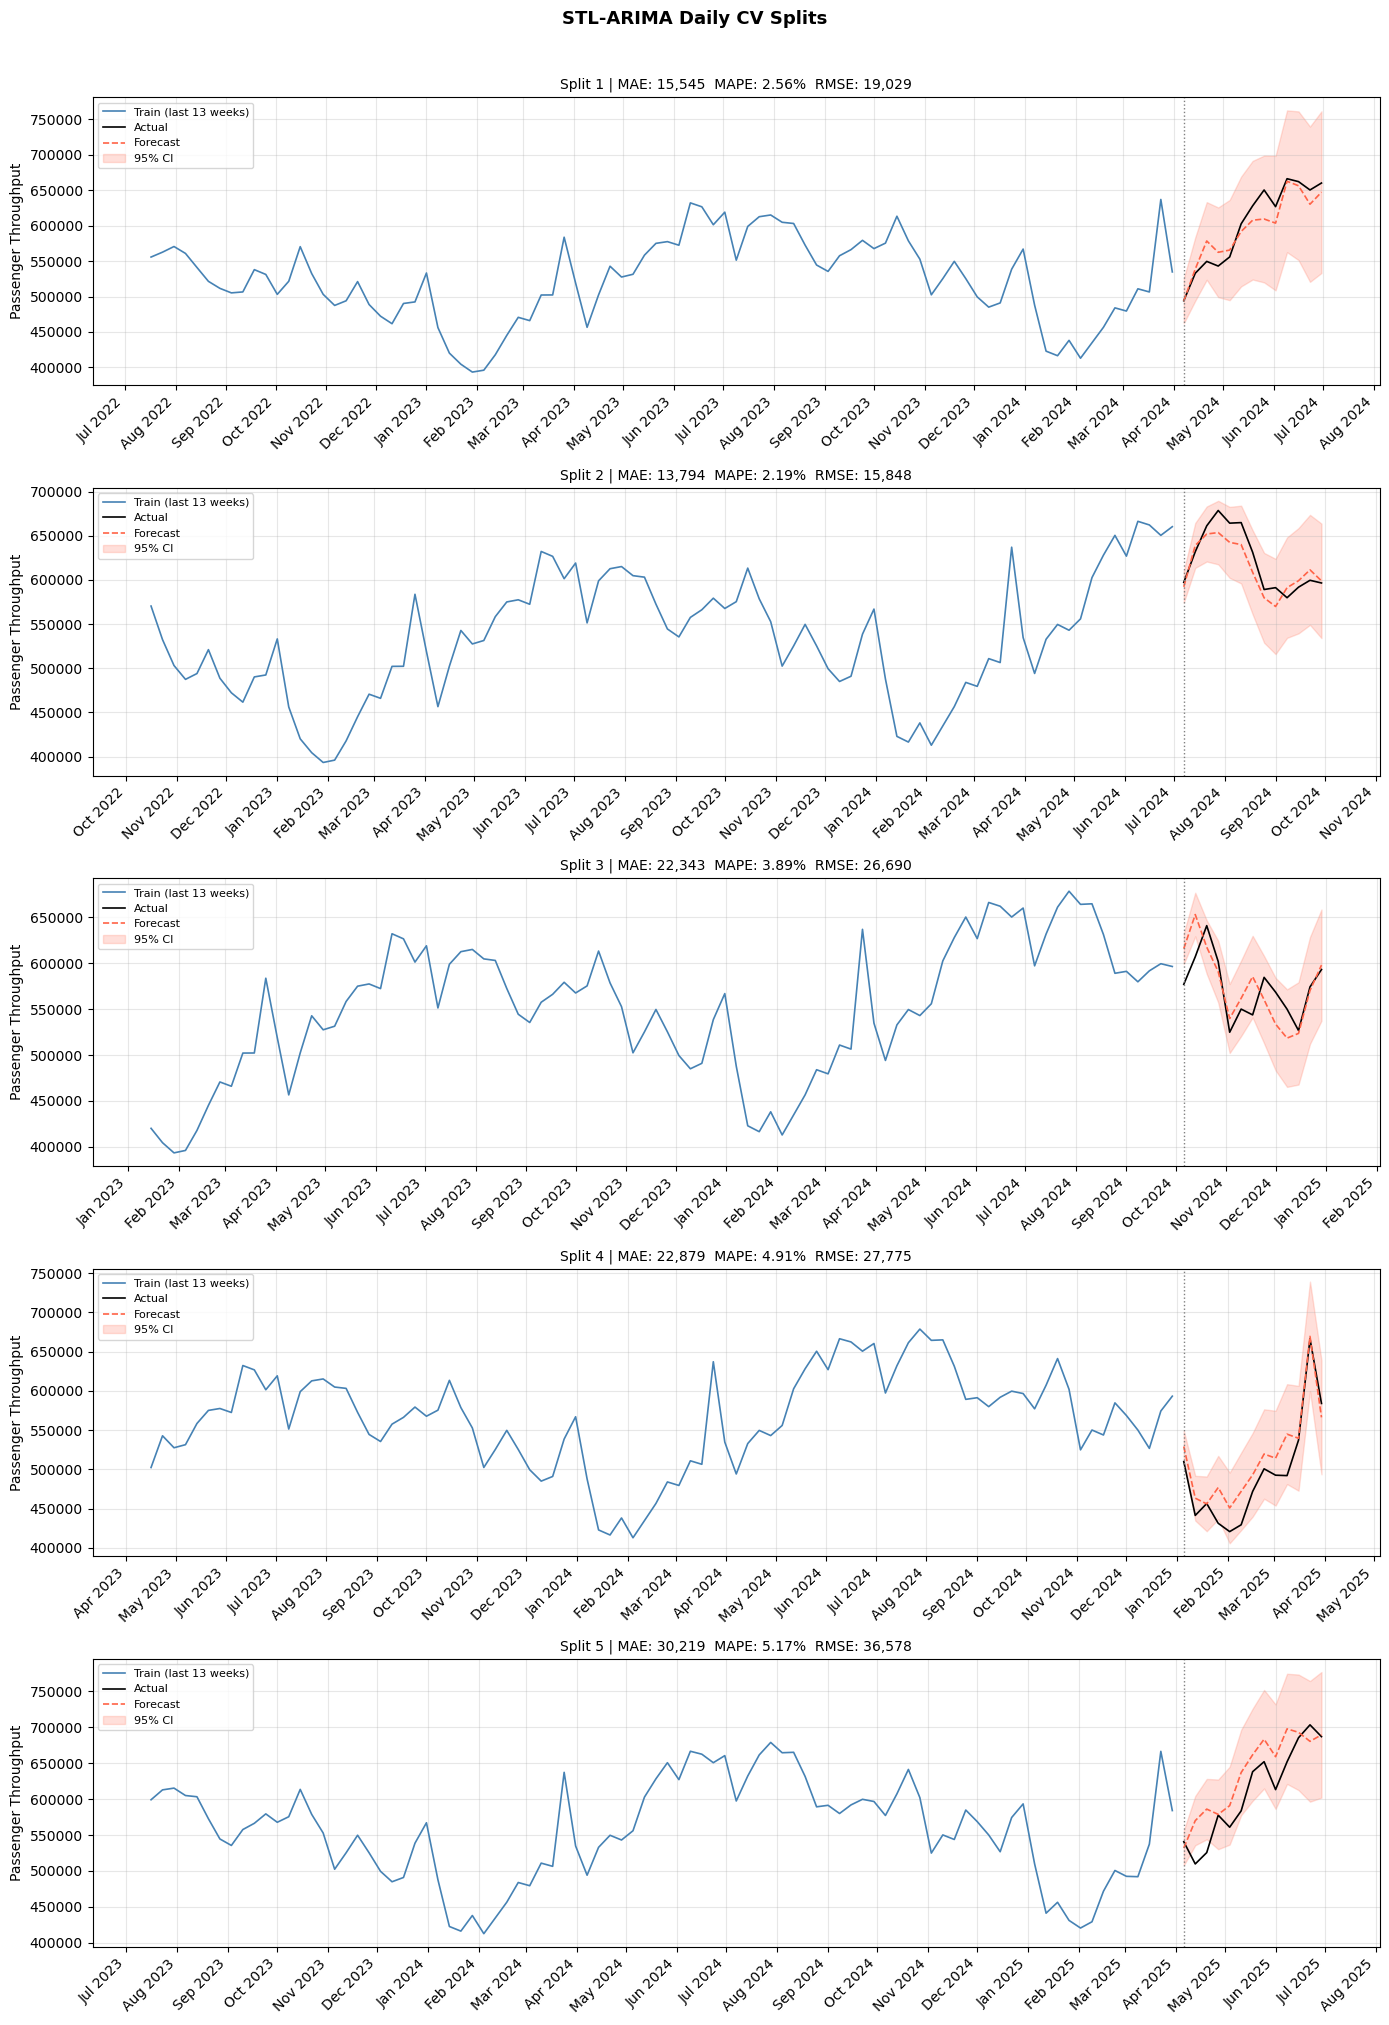

In [16]:


results_stl_w = []
fig, axes = plt.subplots(len(splits_w), 1, figsize=(14, 4 * len(splits_w)))
axes = axes if hasattr(axes, '__len__') else [axes]  # handle single split edge case

for i, (train_idx, test_idx) in enumerate(splits_w):
    ax = axes[i]

    if len(test_idx) == 0:
        print(f"Split {i+1}: empty test set, skipping")
        ax.set_visible(False)
        continue

    train = data_ord_w_train.iloc[train_idx].copy()
    test  = data_ord_w_train.iloc[test_idx].copy()
    n_forecast = len(test_idx)

    model = STLArima(season_length=52, arima_order=(0,1,0), seasonal_order=(0,0,0,0))
    model.fit(train['total_passenger_throughput'])
    forecasts, lower_bound, upper_bound = model.forecast(n_forecast)

    actuals = test['total_passenger_throughput'].values
    metrics = evaluate_forecast(actuals, forecasts, model_name=f"Split {i+1}")
    metrics['split'] = i + 1
    results_stl_w.append(metrics)

    # --- Plotting ---
    train_dates = train.index
    test_dates  = test.index

    # Plot last N days of training data for context
    context_window = min(90, len(train))
    ax.plot(train_dates[-context_window:],
            train['total_passenger_throughput'].values[-context_window:],
            color='steelblue', label='Train (last 13 weeks)', linewidth=1.2)

    # Actuals in test window
    ax.plot(test_dates, actuals,
            color='black', label='Actual', linewidth=1.2)

    # Forecast
    ax.plot(test_dates, forecasts,
            color='tomato', label='Forecast', linewidth=1.2, linestyle='--')

    # 95% Confidence interval
    ax.fill_between(test_dates, lower_bound, upper_bound,
                    color='tomato', alpha=0.2, label='95% CI')

    # Vertical line separating train/test
    ax.axvline(x=test_dates[0], color='gray', linestyle=':', linewidth=1)

    ax.set_title(
        f"Split {i+1} | MAE: {metrics['mae']:,.0f}  "
        f"MAPE: {100*metrics['mape']:.2f}%  "
        f"RMSE: {metrics['rmse']:,.0f}",
        fontsize=10
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_ylabel('Passenger Throughput')
    ax.grid(True, alpha=0.3)

    
plt.suptitle('STL-ARIMA Daily CV Splits', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('stl_arima_cv_splits.png', dpi=150, bbox_inches='tight')
plt.show()
